In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'sans-serif'
sns.set_theme(style="white", context="paper", font_scale=1.2)

SAFE_COLOR = '#4C72B0'
DANGER_COLOR = '#C44E52'
AERO_PALETTE = [SAFE_COLOR, DANGER_COLOR]
COLOR_MAP = {'Safe (0)': SAFE_COLOR, 'Danger (1)': DANGER_COLOR}
print("successful")

successful


In [2]:
file_path = "/kaggle/input/datasets/igormerlinicomposer/f1-aerodynamic-stability-and-porpoising-150k-samp/actaruslab_f1_telemetry_2026.csv"
df = pd.read_csv(file_path)

df['is_porpoising'] = (df['stability_index'] < 90).astype(int)

df['speed_sq'] = df['speed_kmh'] ** 2
df['aero_eff'] = df['downforce_n'] / (df['drag_n'] + 1e-6) 
df['drs_gain'] = df['speed_kmh'] * df['drs_active']
df['setup_agg'] = df['speed_kmh'] * df['wing_angle_deg']

X = df.drop(['stability_index', 'is_porpoising'], axis=1)
y = df['is_porpoising']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)
df.head()

,speed_kmh,wing_angle_deg,drs_active,downforce_n,drag_n,stability_index,is_porpoising,speed_sq,aero_eff,drs_gain,setup_agg
0,199.25,7.08,0,577.87,96.66,100.00,0,39700.5625,5.978378,0.00,1410.6900
1,351.94,22.57,0,5617.09,378.93,44.15,1,123861.7636,14.823556,0.00,7943.2858
2,293.98,28.97,0,4945.14,300.02,77.74,1,86424.2404,16.482701,0.00,8516.6006
3,258.64,27.93,0,3702.69,227.46,100.00,0,66894.6496,16.278423,0.00,7223.8152
4,141.34,30.12,1,1184.59,53.24,100.00,0,19976.9956,22.250000,141.34,4257.1608


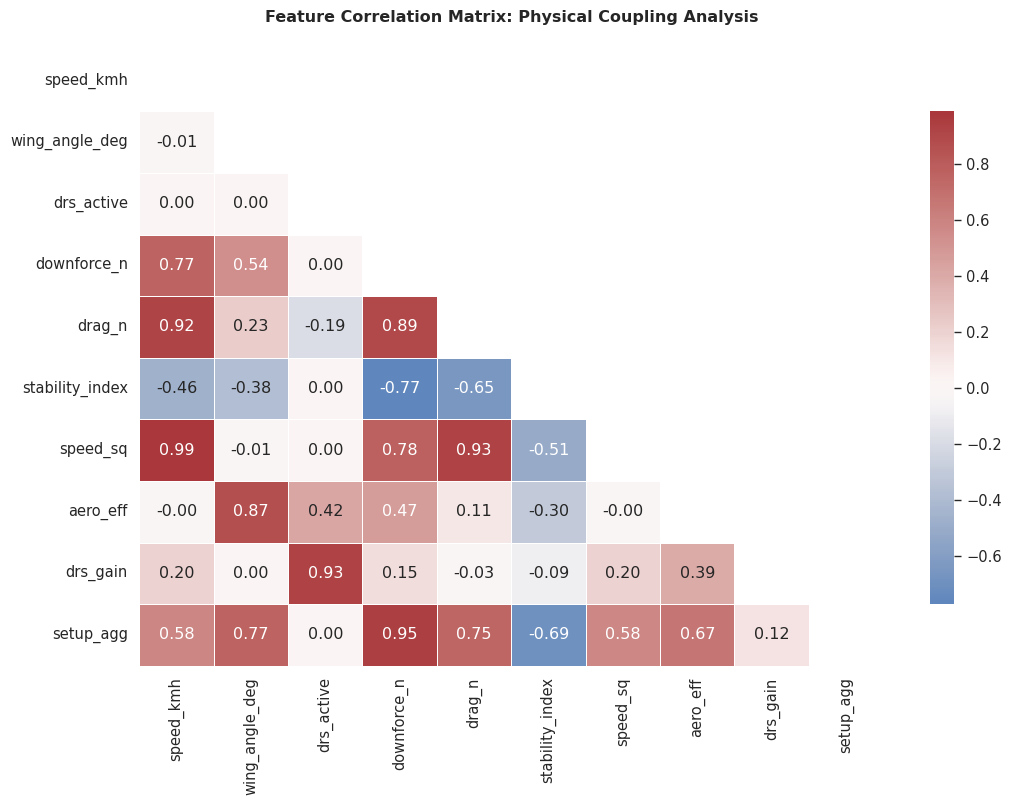

In [3]:
plt.figure(figsize=(12, 8))
corr = df.drop(columns=['is_porpoising']).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, cmap='vlag', center=0, annot=True, fmt=".2f", 
            linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Feature Correlation Matrix: Physical Coupling Analysis', fontweight='bold', pad=20)
plt.show()

In [4]:
clf_xgb = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective='binary:logistic', 
    scale_pos_weight=pos_weight,
    random_state=42,
    n_jobs=-1
)

clf_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

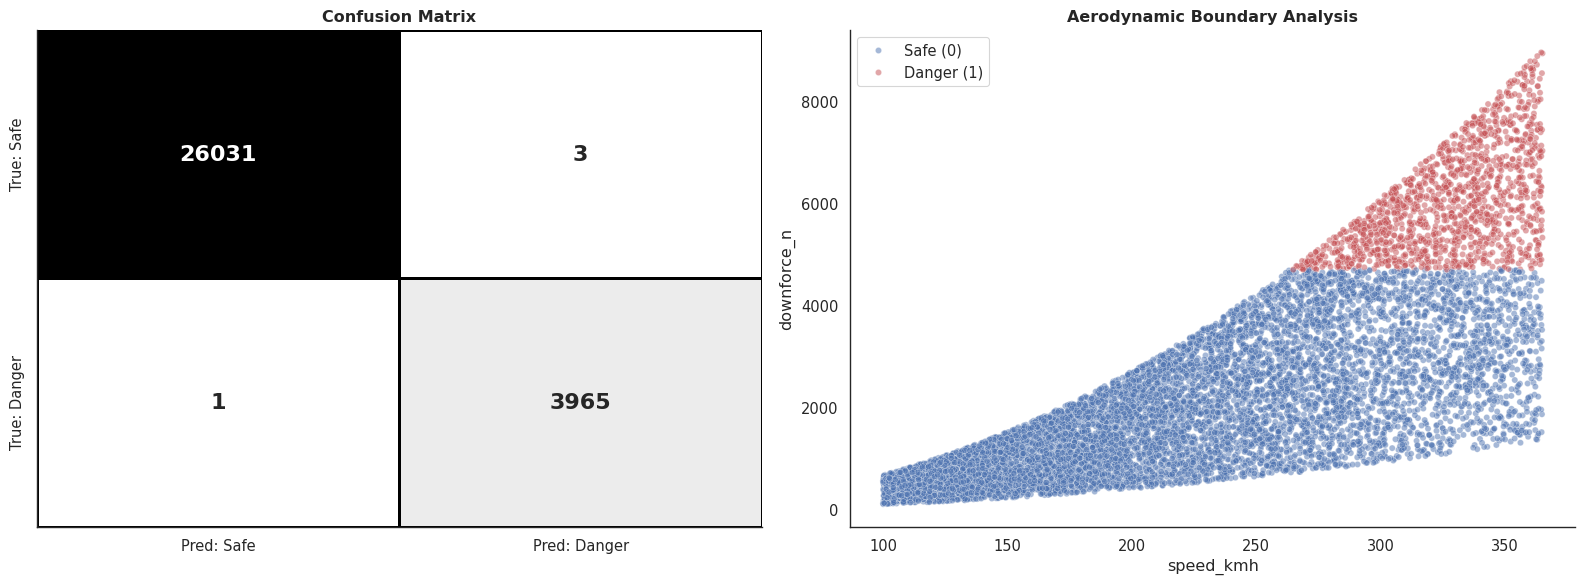

In [5]:
preds = clf_xgb.predict(X_test)
df_res = df.sample(n=10000, random_state=42).copy()
df_res['State'] = df_res['is_porpoising'].map({0: 'Safe (0)', 1: 'Danger (1)'})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False, ax=axes[0],
            annot_kws={"size": 16, "weight": "bold"}, linewidths=1, linecolor='black')
axes[0].set_xticklabels(['Pred: Safe', 'Pred: Danger'])
axes[0].set_yticklabels(['True: Safe', 'True: Danger'])
axes[0].set_title('Confusion Matrix', fontweight='bold')

sns.scatterplot(data=df_res, x='speed_kmh', y='downforce_n', hue='State', 
                palette=COLOR_MAP, alpha=0.5, s=20, ax=axes[1])
axes[1].set_title('Aerodynamic Boundary Analysis', fontweight='bold')
axes[1].legend(title=None, loc='upper left')
sns.despine()

plt.tight_layout()
plt.show()